In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import squidpy as sq

from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.colors import to_hex
import PyComplexHeatmap as pch
import os, sys
import importlib

import random
random.seed(42)
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')

DATA_DIR    = os.path.abspath("../../../data")
RESULTS_DIR = os.path.abspath("../../../results")
SCRIPTS_DIR = os.path.abspath("../../../scripts")
plot_dir = f'{RESULTS_DIR}/figures/plots/main'

## figure settings
def plot_settings():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'legend.fontsize': 12, 
        'axes.linewidth': 1.5,
        'xtick.major.width': 1.0,
        'ytick.major.width': 1.0,
        'axes.spines.top': False,
        'axes.spines.right': False,
    })

/Users/bzhao2/miniforge3/envs/cellcharter-env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/bzhao2/miniforge3/envs/cellcharter-env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [ ]:
adata = sc.read_h5ad(f'{DATA_DIR}/review/Oct222025/all_adata_combined_banksy_metahood.h5ad') 
bdata = sc.read_h5ad(f'{DATA_DIR}/processed/xenium/WT_Mut_catalyst_proseg_prior_expan5um_raw_noBoundary_lowTranscriptLeidenClusterRemoved_Nov25_p46_neuronal_cells_removed_banksy.h5ad')
linearamp_samples = ['p19P', 'p51P', 'p52P','p67P', 'p01P', 'p61P']
ecdna_samples =['p15P', 'p29P', 'p46P','p55P', 'p59P', 'p12P', 'p27P', 'p68P']

In [ ]:
p46p = sc.read_h5ad(f'{DATA_DIR}/review/October062025/data/p46P_filtered_annotated.h5ad')
p67p = sc.read_h5ad(f'{DATA_DIR}/review/October062025/data/p67P_filtered_annotated.h5ad')
p46p_raw = sc.read_h5ad(f'{DATA_DIR}/review/October062025/data/p46P_raw.h5ad')
p67p_raw = sc.read_h5ad(f'{DATA_DIR}/review/October062025/data/p67P_raw.h5ad')
p46p.obs.set_index('cell_id', inplace=True)
p67p.obs.set_index('cell_id', inplace=True)
p46p_raw.obs.set_index('cell_id', inplace=True)
p67p_raw.obs.set_index('cell_id', inplace=True)
p46p.obs['cell_type'] = p46p.obs['cell_type_cnmf_transfered'].tolist()
p67p.obs['cell_type'] = p67p.obs['cell_type_cnmf_transfered'].tolist()
p46p.obsm['spatial'] = p46p_raw[[cid.split('_')[1] for cid in p46p.obs_names]].obsm['spatial']
p67p.obsm['spatial'] = p67p_raw[[cid.split('_')[1] for cid in p67p.obs_names]].obsm['spatial']
p46p.obs['x'] = np.array(p46p.obsm['spatial'][:,0])
p46p.obs['y'] = np.array(p46p.obsm['spatial'][:,1])
p67p.obs['x'] = np.array(p67p.obsm['spatial'][:,0])
p67p.obs['y'] = np.array(p67p.obsm['spatial'][:,1])
p46p.obs['sample'] = 'p46P'
p67p.obs['sample'] = 'p67P'

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MES-like_linearAmp vs. MES-like_ecDNA: Mann-Whitney-Wilcoxon test two-sided, P_val:4.662e-03 U_stat=3.000e+00
Pericyte_linearAmp vs. Pericyte_ecDNA: Mann-Whitney-Wilcoxon test two-sided, P_val:1.998e-02 U_stat=6.000e+00


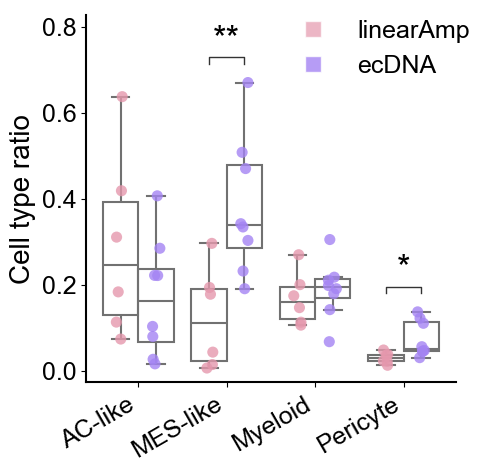

In [17]:
## Figure 5B

from statannotations.Annotator import Annotator

cell_type_counts = adata.obs.groupby('sample')['cell_type'].value_counts()
cell_type_ratio = cell_type_counts / cell_type_counts.groupby(level=0).sum()

# Convert the series to a dataframe for easier plotting
cell_type_ratio_df = cell_type_ratio.to_frame().reset_index()

cell_type_ratio_df['idh'] = cell_type_ratio_df['sample'].map(adata.obs[['sample', 'idh']].drop_duplicates().set_index('sample')['idh'])
# cell_type_ratio_df['idh'] = np.where(cell_type_ratio_df['idh'].str.contains('WT'), 'WT', cell_type_ratio_df['idh'])
cell_type_ratio_df['idh'] = pd.Categorical(cell_type_ratio_df['idh'], categories=['Mut-Codel', 'Mut', 'WT'], ordered=True)

# linearamp_samples = ['p19P', 'p51P', 'p52P','p67P', 'p01P', 'p61P']
# ecdna_samples =['p15P', 'p29P', 'p46P','p55P', 'p59P', 'p12P', 'p27P', 'p22P', 'p68P']
selected_celltypes = ['AC-like', 'MES-like', 'Myeloid', 'Pericyte']
plot_df = cell_type_ratio_df[(cell_type_ratio_df['sample'].isin(linearamp_samples + ecdna_samples))&(cell_type_ratio_df['cell_type'].isin(selected_celltypes))].copy()
plot_df['subtype'] = np.where(plot_df['sample'].isin(linearamp_samples), 'linearAmp', 'ecDNA')
plot_df.drop(columns=['idh'], inplace=True)
plot_df.rename(columns={'count':'ratio'}, inplace=True)
# Define the order of subtypes
plot_df['subtype'] = pd.Categorical(plot_df['subtype'], categories=['linearAmp', 'ecDNA'], ordered=True)
plot_df['cell_type'] = pd.Categorical(plot_df['cell_type'], categories=selected_celltypes, ordered=True)

plt.style.use('default')
plt.rcParams.update({'font.family': 'Arial', 'font.size': 15.5})
fig, ax1 = plt.subplots(1, 1, figsize=(5.2,5))
line_width = 1.5

## custom palette
# amp_colors = {'linearAmp': '#A5CB9B',
#               'ecDNA': '#E06E71'}
amp_colors = {'linearAmp': '#E598AD',
              'ecDNA': '#A484F3'}
sns.boxplot(data=plot_df, 
            x='cell_type', y='ratio', hue='subtype', showfliers=False, legend=False,
            palette=amp_colors,
            boxprops={'facecolor': 'None', 'linewidth': line_width},
            whiskerprops={'linewidth': line_width},
            capprops={'linewidth': line_width},
            medianprops={'linewidth': line_width},
            ax=ax1)
sns.stripplot(data=plot_df, 
              x='cell_type', y='ratio', hue='subtype', dodge=True, 
              palette=amp_colors, marker='o', alpha=0.8, size=8, ax=ax1)

# Add significance stars
box_pairs = [(('AC-like', 'linearAmp'), ('AC-like', 'ecDNA')),
             (('MES-like', 'linearAmp'), ('MES-like', 'ecDNA')),
             (('Myeloid', 'linearAmp'), ('Myeloid', 'ecDNA')),
             (('Pericyte', 'linearAmp'), ('Pericyte', 'ecDNA'))]
annotator = Annotator(ax1, data=plot_df, pairs = box_pairs, x='cell_type', y='ratio', hue='subtype')
annotator.configure(test='Mann-Whitney', text_format='star', line_width=1, loc='inside', hide_non_significant=True, fontsize=25)
annotator.apply_and_annotate()

ax1.set_ylabel('Cell type ratio', fontsize=20)
ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
ax1.set_yticks(np.arange(0, 0.81, 0.2))

sns.despine(ax=ax1, top=True, right=True)

# Create custom legend with square markers
legend_handles = [
    plt.Line2D([0], [0], marker='s', color='w', markersize=11, 
               markerfacecolor=amp_colors['linearAmp'], alpha=0.7, label='linearAmp'),
    plt.Line2D([0], [0], marker='s', color='w', markersize=11, 
               markerfacecolor=amp_colors['ecDNA'], alpha=0.8, label='ecDNA')
]
ax1.legend(handles=legend_handles, title='', bbox_to_anchor=(1.1, 1.05), fontsize=18, frameon=False)
ax1.tick_params(axis='x', labelsize=18)
ax1.tick_params(axis='y', labelsize=18)
# Increase the spine linewidth
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)
plt.tight_layout()
plt.show()

fig.savefig(f'{plot_dir}/Fig.5B.png', dpi=300, bbox_inches='tight')

In [ ]:
## Figure 5D
## Mean distance
import compute_distance
importlib.reload(compute_distance)

## prepare plot data
def plot_mean_distance(source_cell_type, target_cell_type):
    dist_list = []
    for sample in linearamp_samples + ecdna_samples:
        print(sample)
        dist_list.append(
            compute_distance.compute_distances_disturbance(
                adata[adata.obs['sample'] == sample],
                sample,
                source_cell_type=source_cell_type,
                target_cell_type=target_cell_type
            )
        )
    dist_df = pd.concat(dist_list, ignore_index=True)
    dist_df['group'] = np.where(dist_df['sample'].isin(linearamp_samples), 'linearAmp', 'ecDNA')

    fig, ax = plt.subplots(figsize=(4.5, 5.3))
    sns.violinplot(
        data=dist_df, x='group', y='distance', hue='group',
        palette=amp_colors, inner=None, alpha=0.8, ax=ax, cut=0
    )
    sns.boxplot(
        data=dist_df, x='group', y='distance', hue='group',
        width=0.1, showcaps=False, showfliers=False,
        boxprops={'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.2},
        whiskerprops={'color': 'black', 'linewidth': 1.2},
        medianprops={'color': 'red', 'linewidth': 2},
        saturation=0.5, ax=ax
    )
    box_pairs = [('linearAmp', 'ecDNA')]
    annotator = Annotator(ax, box_pairs, data=dist_df, x='group', y='distance')
    annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=2, fontsize=25)
    annotator.apply_and_annotate()
    ax.set_ylabel(f'Distance from {source_cell_type} to \nnearest {target_cell_type} (µm)')
    ax.set_xlabel('')
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(axis='both', labelsize=16)
    plt.tight_layout()
    plt.savefig(f'{plot_dir}/Fig.5C_{source_cell_type}_{target_cell_type}.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_settings()
# Example usage
plot_mean_distance('MES-like', 'Pericyte')

In [42]:
## Figure 5F

# Collect EGFR expression for all samples
egfr_exp_list = []
all_samples = linearamp_samples + ecdna_samples
selected_cell_types = ['AC-like', 'MES-like']

for sample in all_samples:
    if sample == 'p46P':
        egfr_exp = p46p.to_df()[['EGFR']]
        egfr_exp['cell_type'] = egfr_exp.index.map(p46p.obs['cell_type'])
        egfr_exp = egfr_exp[egfr_exp['cell_type'].isin(selected_cell_types)]
        egfr_exp['sample'] = sample
        egfr_exp_list.append(egfr_exp)
    elif sample == 'p67P':
        egfr_exp = p67p.to_df()[['EGFR']]
        egfr_exp['cell_type'] = egfr_exp.index.map(p67p.obs['cell_type'])
        egfr_exp = egfr_exp[egfr_exp['cell_type'].isin(selected_cell_types)]
        egfr_exp['sample'] = sample
        egfr_exp_list.append(egfr_exp)
    else:
        sample_adata = adata[adata.obs['sample'] == sample]
        egfr_exp = sample_adata.to_df()[['EGFR']]
        egfr_exp['cell_type'] = egfr_exp.index.map(sample_adata.obs['cell_type'])
        egfr_exp = egfr_exp[egfr_exp['cell_type'].isin(selected_cell_types)]
        egfr_exp['sample'] = sample
        egfr_exp_list.append(egfr_exp)

# for sample in all_samples:
#     sample_adata = adata[adata.obs['sample'] == sample]
#     egfr_exp = sample_adata.to_df()[['EGFR']]
#     egfr_exp['cell_type'] = egfr_exp.index.map(sample_adata.obs['cell_type'])
#     egfr_exp = egfr_exp[egfr_exp['cell_type'].isin(selected_cell_types)]
#     egfr_exp['sample'] = sample
#     egfr_exp_list.append(egfr_exp)

egfr_df = pd.concat(egfr_exp_list, ignore_index=True)
egfr_df = egfr_df[egfr_df['EGFR'] > 0]  # Filter out zero expression values
egfr_df['cell_type'] = pd.Categorical(egfr_df['cell_type'], categories=['AC-like', 'MES-like'], ordered=True)
egfr_df['group'] = egfr_df['sample'].map(lambda x: 'linearAmp' if x in linearamp_samples else 'ecDNA')
egfr_df['group'] = pd.Categorical(egfr_df['group'], categories=['linearAmp', 'ecDNA'], ordered=True)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MES-like_linearAmp vs. MES-like_ecDNA: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=1.168e+09
AC-like_linearAmp vs. AC-like_ecDNA: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=2.147e+09


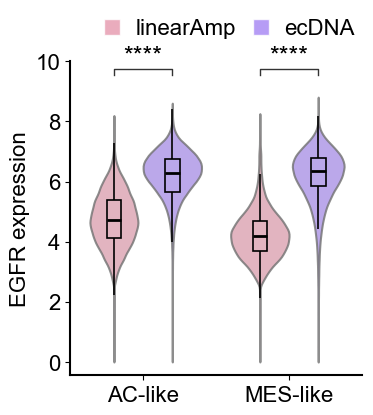

In [43]:

# Create figure for comparison
fig, ax = plt.subplots(figsize=(4, 4.5))
# Create violin plot with box plot inside
sns.violinplot(data=egfr_df, x='cell_type', y='EGFR', hue='group', 
               split=False, inner=None, palette=amp_colors, alpha=0.8,
               cut=0, linewidth=1.5, ax=ax)

# Add significance stars
box_pairs = [(('AC-like', 'linearAmp'), ('AC-like', 'ecDNA')),
             (('MES-like', 'linearAmp'), ('MES-like', 'ecDNA'))]
annotator = Annotator(ax, data=egfr_df, pairs=box_pairs, x='cell_type', y='EGFR', hue='group')
annotator.configure(test='Mann-Whitney', text_format='star', line_width=1, 
                    loc='outside', hide_non_significant=True, 
                    fontsize=18)
annotator.apply_and_annotate()

# Add individual data points with jitter
# Add a boxplot inside but with clean styling
# Define hue categories and spacing
hue_order = ['linearAmp', 'ecDNA']  # Keep the same order as in the violin plot
n_hues = len(hue_order)
offsets = np.linspace(-0.2, 0.2, n_hues)  # Adjust spacing

# Get x positions for cell types
x_pos = np.arange(len(ax.get_xticks()))

# Adjust positions manually for each hue category
for i, hue in enumerate(hue_order):
    subset = egfr_df[egfr_df['group'] == hue]
    for j, cell_type in enumerate(subset['cell_type'].unique()):
        sns.boxplot(data=subset[subset['cell_type'] == cell_type], x='cell_type', y='EGFR',
                    width=0.1, showcaps=False, showfliers=False,
                    boxprops={'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.2},
                    whiskerprops={'color': 'black', 'linewidth': 1.2},
                    medianprops={'color': 'black', 'linewidth': 2},
                    saturation=0.5, ax=ax,
                    positions=[x_pos[j] + offsets[i]])  # Apply manual offset
# Improve styling
ax.set_xlabel('')
ax.set_ylabel('EGFR expression')
ymin, _ = ax.get_ylim()
ax.set_ylim(ymin, 10)
# Create custom legend handles with square markers
ccode_1=0; ccode_2=1
legend_handles = [
    plt.Line2D([0], [0], marker='s', color='w', markersize=11, markerfacecolor=amp_colors['linearAmp'], alpha=0.8, label='linearAmp'),
    plt.Line2D([0], [0], marker='s', color='w', markersize=11, markerfacecolor=amp_colors['ecDNA'], alpha=0.8, label='ecDNA')
]
ax.legend(handles=legend_handles, title='', bbox_to_anchor=(0, 1.2), loc='upper left', 
          frameon=False, ncol=2, 
          columnspacing=0.1, handletextpad=0.05)

sns.despine(top=True, right=True)
# Increase spine linewidth for better visibility
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
# plt.savefig(f'{plot_dir}/Fig.5F_EGFR_expression.png', dpi=300, bbox_inches='tight')
plt.show()

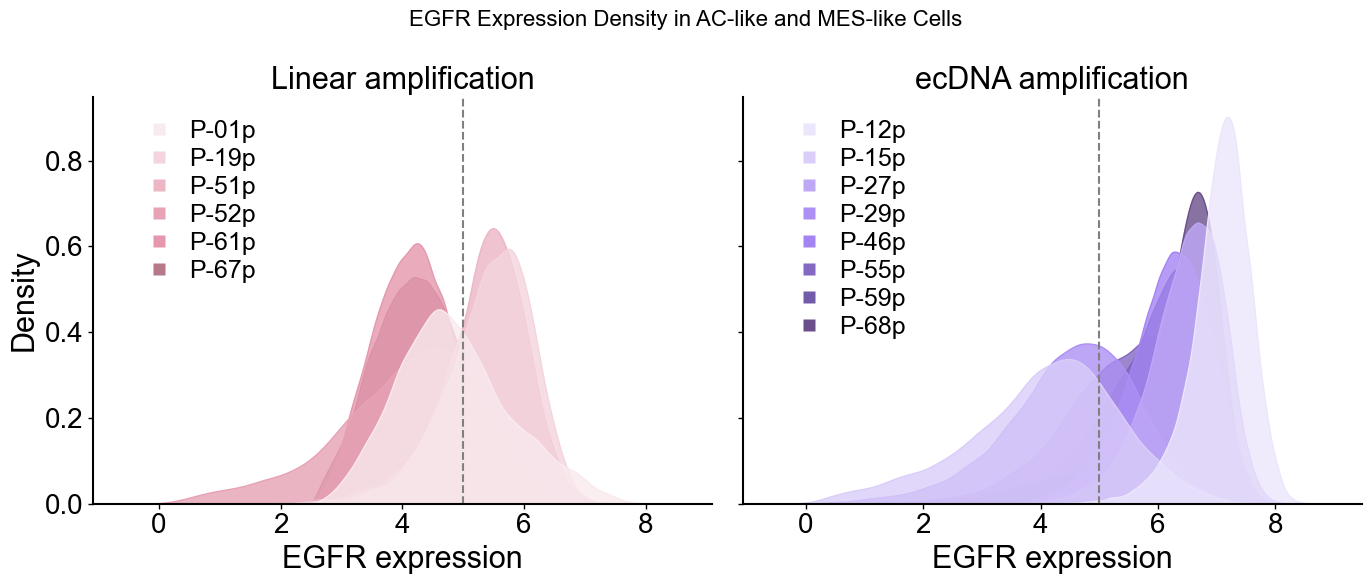

In [102]:
## Figure 5E-G
## Fig 5E
# Prepare data for EGFR expression in AC-like and MES-like cells
# Prepare EGFR data for adata, p46p, and p67p separately

## Figure 5E

# custom_colors = {
#     'p01P': '#E74C3C',      # Red
#     'p61P': '#3498DB',      # Blue
#     'p67P': '#2ECC71',      # Green
#     'p12P': '#F39C12',      # Orange
#     # 'p22P': '#9B59B6',      # Purple
#     'p27P': '#1ABC9C',      # Teal
#     'p46P': '#E67E22',      # Dark Orange
#     'p68P': '#34495E',       # Dark Gray
# }

# custom_colors = {
#     'p01P': '#F3BAC2',      
#     'p61P': '#C598CD',      
#     'p67P': '#A883FD', 

#     'p12P': '#E598AD',      
#     # 'p22P': '#9B59B6',     
#     'p27P': '#DF804F',      
#     'p46P': '#C95289',      
#     'p68P': '#F2A93B',      
# }

custom_colors = {
    'p01P': '#f9eaee',      
    'p19P': '#f4d5de',
    'p51P':'#ecb6c5',
    'p52P':'#e7a2b5',
    'p61P': '#e598ad',      
    'p67P': '#b7798a',

    'p12P': '#ece6fc', 
    'p15P': '#dacdfa',     
    # 'p22P': '#9B59B6',     
    'p27P': '#bfa8f6', 
    'p29P': '#ad90f4',     
    'p46P': '#a484f3',      
    'p55P':'#8369c2', 
    'p59P': '#725caa',
    'p68P': '#6a4f8a'
}

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns

# plot_settings()
plt.rcParams.update({'font.size': 16})



fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Linear samples ---

linearamp_samples_sorted = natsort.natsorted(linearamp_samples)
ecdna_samples_sorted = natsort.natsorted(ecdna_samples)
linearamp_samples_renamed  = [f"P-{i[1:3]}{i[3].lower()}" for i in linearamp_samples_sorted]
ecdna_samples_renamed = [f"P-{i[1:3]}{i[3].lower()}" for i in ecdna_samples_sorted]

linear_mask = egfr_df['sample'].isin(linearamp_samples_sorted)
df1 = egfr_df.loc[linear_mask & (egfr_df['EGFR'] > 0)].copy()
df1['sample'] = pd.Categorical(df1['sample'], categories=linearamp_samples_sorted, ordered=True)
# palette for linear (ensure keys exist)
palette_linear = {k: v for k, v in custom_colors.items() if k in linearamp_samples_sorted}

sns.kdeplot(
    data=df1,
    x='EGFR', hue='sample', fill=True, common_norm=False, ax=axes[0],
    palette=palette_linear,alpha=0.8,
    legend=False  # disable seaborn auto-legend
)
axes[0].set_title('Linear amplification', x=0.5)
axes[0].set_xlabel('EGFR expression', fontsize=18)
axes[0].axvline(x=5, color='gray', linestyle='--', linewidth=1.5)


# Create manual legend handles in the same order as categories
# handles_linear = [
#     Patch(facecolor=palette_linear[s], label=str(s)) for s in linearamp_samples if s in palette_linear
# ]
handles_linear = [
    Line2D([0], [0], marker='s', linestyle='None', markersize=8,
           markerfacecolor=palette_linear[s], markeredgecolor='none', label=linearamp_samples_renamed[i])  #label=str(s)
    for i, s in enumerate(linearamp_samples_sorted) if s in palette_linear
]

if handles_linear:
    axes[0].legend(handles=handles_linear, title='', bbox_to_anchor=(0.3,1), 
                   handletextpad=0.2, columnspacing=0.1,labelspacing=0.2,
                   fontsize=18, frameon=False, loc='upper right')

# --- ecDNA samples ---
ecdna_mask = egfr_df['sample'].isin(ecdna_samples)
df2 = egfr_df.loc[ecdna_mask & (egfr_df['EGFR'] > 0)].copy()
df2['sample'] = pd.Categorical(df2['sample'], categories=ecdna_samples_sorted, ordered=True)

palette_ecdna = {k: v for k, v in custom_colors.items() if k in ecdna_samples}

sns.kdeplot(
    data=df2,
    x='EGFR', hue='sample', fill=True, common_norm=False, ax=axes[1],
    palette=palette_ecdna,alpha=0.8,
    legend=False, 
)
axes[1].set_title('ecDNA amplification', x=0.5)
axes[1].set_xlabel('EGFR expression', fontsize=18)
axes[1].axvline(x=5, color='gray', linestyle='--', linewidth=1.5)

# axes[1].tick_params(width=2)


handles_ecdna = [
    Line2D([0], [0], marker='s', linestyle='None', markersize=8,
           markerfacecolor=palette_ecdna[s], markeredgecolor='none', label=ecdna_samples_renamed[i])
    for i, s in enumerate(ecdna_samples_sorted) if s in palette_ecdna
]

if handles_ecdna:
    axes[1].legend(handles=handles_ecdna, title='', frameon=False, fontsize=18, 
                handletextpad=0.2, columnspacing=0.1,labelspacing=0.2,
                   bbox_to_anchor=(0.3,1), loc='upper right')

# Styling
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Set label and title font sizes for both axes
    ax.xaxis.label.set_size(22)
    ax.yaxis.label.set_size(22)
    ax.title.set_size(22)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(axis='both', labelsize=20)


plt.suptitle('EGFR Expression Density in AC-like and MES-like Cells', fontsize=16)
plt.tight_layout()
plt.savefig(f"{plot_dir}/egfr_density_linear_vs_ecdna.png", dpi=300, bbox_inches='tight')
plt.show()


In [72]:
# Figure 5G
import glob
from pathlib import Path

import glob
import natsort
clustered_csv_files = glob.glob('/Users/bzhao2/Library/CloudStorage/OneDrive-InsideMDAnderson/akdemirlab-projects/01_catalyst/review/figures/data/transcript_clustering/*.csv')
# Exclude files containing 'p46P' or 'p67P' and 'proseg' in the filename
clustered_csv_files = [f for f in clustered_csv_files if not (('p46P' in f or 'p67P' in f) and 'proseg' in f)]
# exclude 'p22P' as well
res_csv = [f for f in clustered_csv_files if 'p22P' not in f]

kdtree_res, dbscan_res = [], []
for f in res_csv:
    sample = Path(f).name.split('_')[0]
    if 'kdtree' in Path(f).name:
        df = pd.read_csv(f)
        df['sample'] = sample
        kdtree_res.append(df)
    elif 'dbscan' in Path(f).name:
        df = pd.read_csv(f)
        df['sample'] = sample
        dbscan_res.append(df)
kdtree_res_all = pd.concat(kdtree_res, ignore_index=True)
kdtree_res_all = kdtree_res_all[kdtree_res_all['cluster_id'].notna()]
# kdtree_res_all['sample'] = pd.Categorical(kdtree_res_all['sample'], ['p01P', 'p61P', 'p67P','p12P', 'p27P', 'p46P',  'p68P'])
dbscan_res_all = pd.concat(dbscan_res, ignore_index=True)
dbscan_res_all = dbscan_res_all[dbscan_res_all['cluster_id'].notna()]
# dbscan_res_all['sample'] = pd.Categorical(dbscan_res_all['sample'], ['p01P', 'p61P', 'p67P','p12P', 'p27P', 'p46P',  'p68P'])


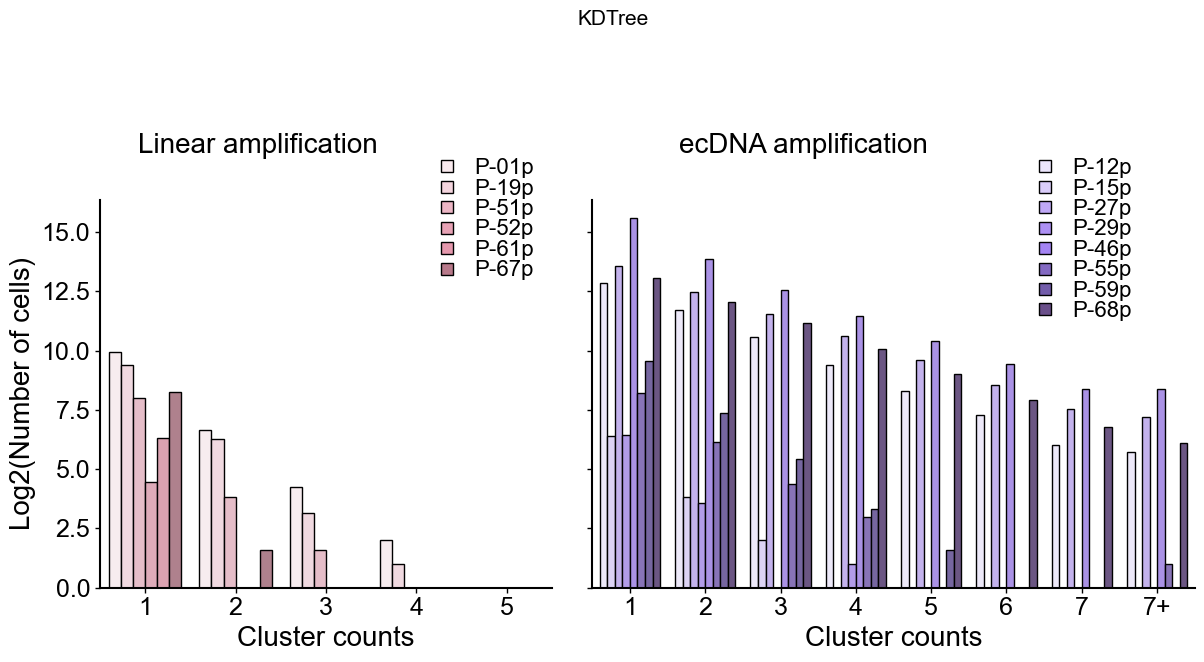

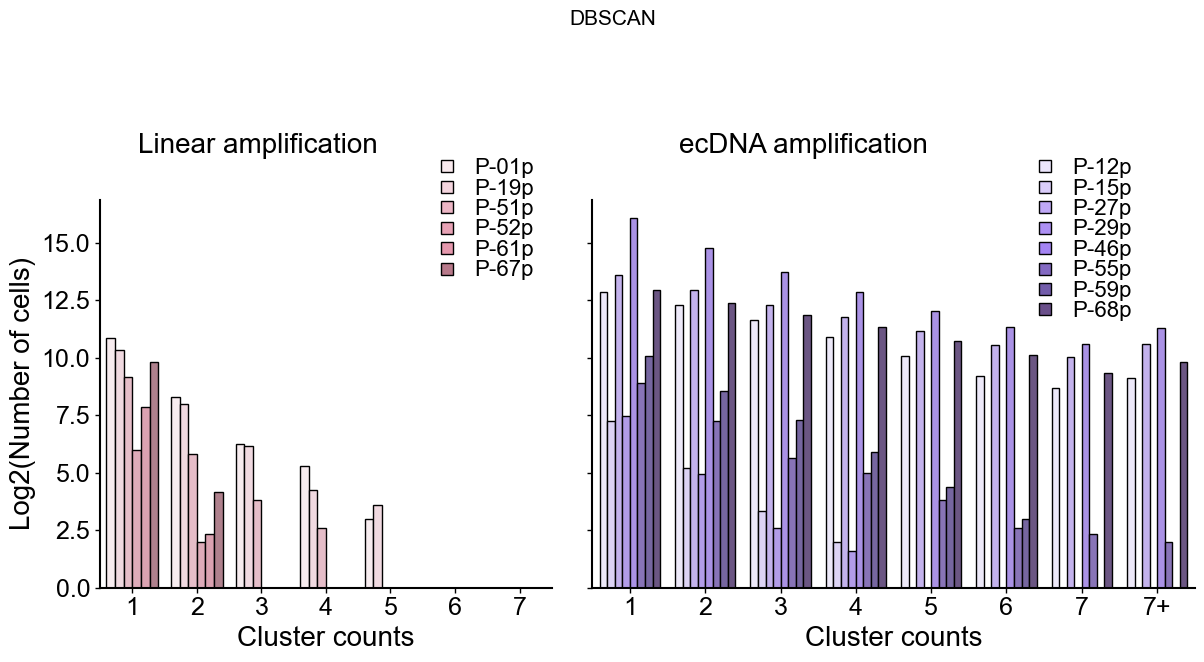

In [108]:

def summarize_clusters(res_all, log2=False, title=None, colors=None, sample_order=None, savefig=False):
    """
    Summarize and visualize cluster distributions with two subplots:
    - Left: Linear samples (p01P, p61P, p67P)
    - Right: Remaining samples
    
    Args:
        res_all: DataFrame with columns 'sample', 'cell_id'
        log2: Whether to log2 transform the y-axis
        title: Plot title (will be used as suptitle)
        colors: Dict mapping sample names to colors. If None, uses default palette.
                Example: {'p01P': '#E74C3C', 'p61P': '#3498DB', ...}
        sample_order: List of sample names in desired order for legend and plot.
                     Example: ['p01P', 'p61P', 'p67P', 'p12P', 'p22P', 'p27P', 'p46P', 'p68P']
                     If None, uses alphabetical order.
    
    Returns:
        DataFrame with cluster summary
    """
    # Aggregate data
    df_clusters = res_all.groupby(['sample', 'cell_id']).size().to_frame()\
        .reset_index().rename(columns={0: 'ncluster'})
    df_clusters = df_clusters.groupby(['sample', 'ncluster']).size().to_frame()\
        .reset_index().rename(columns={0: 'n_cells'})
    
    # Bin clusters: group 7+ into single category
    df_clusters['ncluster_2'] = np.where(df_clusters['ncluster'] > 7, '7+',
                                          df_clusters['ncluster'].astype(str))
    df_clusters['n_cells_2'] = df_clusters.groupby(['sample', 'ncluster_2'])['n_cells']\
        .transform('sum')
    df_clusters.drop_duplicates(subset=['sample', 'ncluster_2', 'n_cells_2'], inplace=True)
    
    # Log2 transform if requested
    ycol = 'n_cells_2'
    if log2:
        ycol = 'log2_n_cells_2'
        df_clusters[ycol] = np.log2(df_clusters['n_cells_2'])
    
    # Filter data
    plot_data = df_clusters[df_clusters['ncluster'] > 0].copy()
    
    # Define linear and remaining samples
    linear_samples = linearamp_samples_sorted
    
    # Set up sample order
    available_samples = sorted(plot_data['sample'].unique())
    if sample_order is None:
        samples = available_samples
    else:
        # Use provided order, filter to only samples in plot_data
        samples = [s for s in sample_order if s in available_samples]
    
    # Split samples into linear and remaining
    linear_subset = [s for s in samples if s in linear_samples]
    remaining_subset = [s for s in samples if s not in linear_samples]
    
    # Set up colors
    if colors is None:
        # Default palette
        palette = sns.color_palette("husl", len(samples))
        colors = {sample: palette[i] for i, sample in enumerate(samples)}
    
    # Create figure with two subplots
    # Calculate the number of samples in each subplot
    n_linear = len(linear_subset)
    n_remaining = len(remaining_subset)
    total = n_linear + n_remaining

    # Avoid division by zero
    if total == 0:
        widths = [1, 1]
    else:
        widths = [n_linear / total, n_remaining / total]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': widths})
    
    # Define subplot data and titles
    # subplot_data = [
    #     (linear_subset, 'Linear samples', axes[0]),
    #     (remaining_subset, 'ecDNA samples', axes[1])
    # ]
    subplot_data = [
        (linear_subset, 'Linear amplification', axes[0]),
        (remaining_subset, 'ecDNA amplification', axes[1])
    ]
    
    for sample_list, subplot_title, ax in subplot_data:
        if not sample_list:
            ax.set_visible(False)
            continue
        
        # Filter data for this subplot
        subset_data = plot_data[plot_data['sample'].isin(sample_list)].copy()
        
        if subset_data.empty:
            ax.set_visible(False)
            continue
        
        # Set up color palette for this subplot
        palette_dict = {sample: colors.get(sample, '#808080') for sample in sample_list}
        
        # Plot using sns.barplot
        sns.barplot(
            data=subset_data,
            x='ncluster_2',
            y=ycol,
            hue='sample',
            palette=palette_dict,
            hue_order=sample_list,
            ax=ax,
            edgecolor='black'  # Add edge color to bars
        )
        
        # Customize axes
        ax.set_xlabel('Cluster counts', fontsize=14)
        # ax.set_title(subplot_title, fontsize=13, y=1.1,fontweight='bold')
        ax.set_title(subplot_title, fontsize=13, x=0.35, y=1.1)
        
        # Only show y-label on first subplot
        if ax == axes[0]:
            if log2:
                ax.set_ylabel('Log2(Number of cells)', fontsize=14)
            else:
                ax.set_ylabel('Number of cells', fontsize=14)
        else:
            ax.set_ylabel('')
        
        # Remove default legend
        if ax.legend_:
            ax.legend_.remove()
        
        # Create custom legend with square markers
        handles = []
        for sample in sample_list:
            color = colors.get(sample, '#808080')
            # Change sample name for legend label, e.g., p01P -> P-01p
            # Rename sample for legend: e.g., p01P -> P-01p, p61P -> P-61p, etc.
            label = f"P-{sample[1:3]}p" if sample in samples else sample
            handle = Line2D([0], [0], marker='s', color='w',
                          markerfacecolor=color, markersize=8,
                          markeredgecolor='black', markeredgewidth=1,
                          label=label)
            handles.append(handle)
        
        # Add legend
        ax.legend(handles=handles, title='',
                 bbox_to_anchor=(0.7, 1.13), loc='upper left',
                handletextpad=0.2, borderaxespad=0.0, labelspacing=0.02,
                 frameon=False, fontsize=16)
        
        # Remove spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.xaxis.label.set_size(20)
        ax.yaxis.label.set_size(20)
        ax.title.set_size(20)
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['left'].set_linewidth(1.5)
        ax.tick_params(axis='both', labelsize=18)
    
    # Add overall title if provided
    if title is not None:
        # fig.suptitle(title, fontsize=15, fontweight='bold', y=1.1)
        fig.suptitle(title, fontsize=15, y=1.1)
    
    plt.tight_layout()
    if savefig:
        plt.savefig(f"{plot_dir}/{title.replace(' ', '_').lower()}_cluster_counts.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    return df_clusters

plot_settings()
# plt.rcParams.update({'font.family': 'Arial', 'font.size': 14})
kdtree_clusters = summarize_clusters(kdtree_res_all, log2=True, title='KDTree', colors=custom_colors, sample_order=linearamp_samples_sorted + ecdna_samples_sorted, savefig=True)
dbscan_clusters = summarize_clusters(dbscan_res_all, log2=True, title='DBSCAN', colors=custom_colors, sample_order=linearamp_samples_sorted + ecdna_samples_sorted, savefig=True)